#### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR(MULTIPLE LINEAR REGRESSION)

Load Dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


Basic Info & Statistics

In [45]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Visualizations

1. Distribution of Price

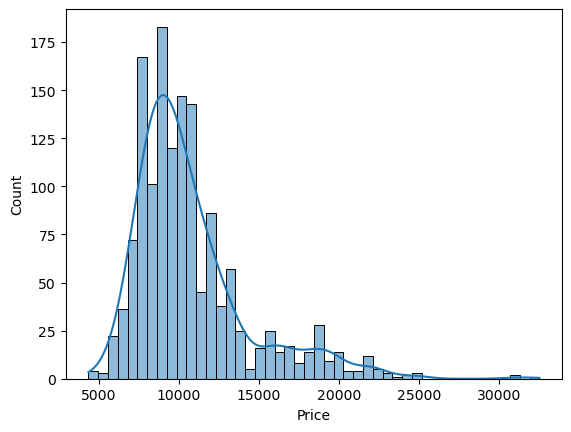

In [46]:
sns.histplot(df['Price'], kde=True)
plt.show()

2. Correlation Heatmap

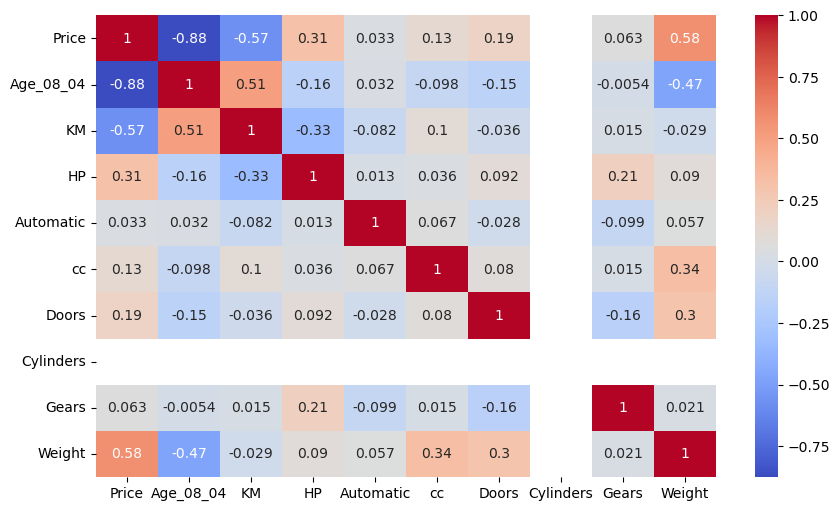

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

3. Scatter Plots (Important Relationships)

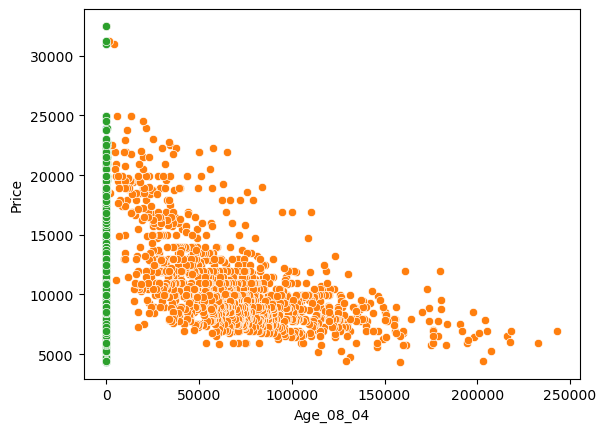

In [48]:
sns.scatterplot(x='Age_08_04',y='Price', data=df)
sns.scatterplot(x='KM',y='Price', data=df)
sns.scatterplot(x='HP',y='Price', data=df)
plt.show()

Data Preprocessing

Convert Categorical Data

In [49]:
df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol':0, 'Diesel':1, 'CNG':2})

Feature Selection

In [50]:
X = df[['Age_08_04','KM','Fuel_Type','HP','Automatic','cc','Doors','Weight']]
y = df['Price']

#### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.

🔹 Model 1: All Features

In [30]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Intercept:", model1.intercept_)
print("Coefficients:", list(zip(X.columns, model1.coef_)))

Intercept: -8601.765871766605
Coefficients: [('Age_08_04', np.float64(-121.40491183418061)), ('KM', np.float64(-0.016614242360377417)), ('Fuel_Type', np.float64(-894.8981956266423)), ('HP', np.float64(22.066892068516253)), ('Automatic', np.float64(187.66328519412693)), ('cc', np.float64(-0.07165897819395718)), ('Doors', np.float64(-60.51621656868859)), ('Weight', np.float64(23.782971033640795))]


Model 2: Selected Important Features

In [33]:
X2 = df[['Age_08_04','KM','HP','Weight']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model 3: Removing Weak Features

In [36]:
X3 = df[['Age_08_04','KM','HP','cc','Weight']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("Model 1:")
evaluate(model1, X_test, y_test)

print("\nModel 2:")
evaluate(model2, X2_test, y2_test)

print("\nModel 3:")
evaluate(model3, X3_test, y3_test)

Model 1:
R2 Score: 0.8411467309385152
RMSE: 1455.8659368977408

Model 2:
R2 Score: 0.8506068681500583
RMSE: 1411.8502091132298

Model 3:
R2 Score: 0.8504087218447197
RMSE: 1412.786196593583


#### 5.Apply Lasso and Ridge methods on the model.

Ridge Regression

In [38]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

evaluate(ridge, X_test, y_test)

R2 Score: 0.8413039110747449
RMSE: 1455.1454926745294


Lasso Regression

In [39]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

evaluate(lasso, X_test, y_test)

R2 Score: 0.8411633985741367
RMSE: 1455.7895567273843


#### interview

#### 1. What is Normalization & Standardization? How are they helpful?

Normalization

In [ ]:
Scales data into a fixed range (usually 0 to 1)
Data does not follow normal distribution
Features have different scales

In [ ]:
Standardization

Transforms data to:
  Z=x-μ/σ

Mean (μ) = 0
Standard deviation (σ) = 1

Data is normally distributed
Algorithms assume Gaussian distribution

Why they are helpful
Bring all features to same scale
Improve model accuracy
Speed up gradient descent
Required for:
K-Means
KNN
SVM

#### 2. Techniques to Address Multicollinearity in Multiple Linear Regression

What is Multicollinearity?
When independent variables are highly correlated
Techniques to fix it
1. Remove correlated features
Use correlation matrix
Drop one variable
2. Variance Inflation Factor (VIF)
Detect multicollinearity
Rule:
VIF > 10 → problem
3. Feature Selection
Forward selection
Backward elimination
Stepwise regression
4. Principal Component Analysis (PCA)
Converts correlated variables → uncorrelated components
5. Regularization
Ridge Regression → reduces coefficients
Lasso Regression → removes features
 6. Increase sample size
More data → reduces correlation impact
7. Combine variables
Example: create ratio or average
